In [48]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import seaborn as sns



In [2]:
# Load dataset
from google.colab import files

uploaded = files.upload()

# Reading CSV
data = pd.read_csv('Copy of National_Syndromic_Surveillance_Program_(NSSP)_Mental_Health-Related_Emergency_Department_Visit_Rates_20260710.csv')

Saving Copy of National_Syndromic_Surveillance_Program_(NSSP)_Mental_Health-Related_Emergency_Department_Visit_Rates_20260710.csv to Copy of National_Syndromic_Surveillance_Program_(NSSP)_Mental_Health-Related_Emergency_Department_Visit_Rates_20260710.csv


## Data Inspection



In [3]:
# Display first few rows
data.head()

# Checking for Data Types
# data.info()

,month_end,condition,demographics_type,demographics_values,rate_per_100000_visits
0,2026-05,Anxiety Disorders,Age,12-17 years,2160
1,2026-05,Anxiety Disorders,Age,18-34 years,2864
2,2026-05,Anxiety Disorders,Age,35-64 years,3171
3,2026-05,Anxiety Disorders,Age,65+ years,2838
4,2026-05,Anxiety Disorders,Age,All,2636


In [4]:
# Summary Statistics
data.describe()


,rate_per_100000_visits
count,10591.000000
mean,1627.445095
std,1880.010766
min,22.000000
25%,348.000000
50%,632.000000
75%,2409.000000
max,11967.000000


In [5]:
# rows, columns
data.shape


(10591, 5)

In [6]:
# Return every unique value in the column
data['condition'].unique()

data['demographics_type'].unique()



array(['Age', 'RaceEthnicity', 'Sex', 'Total'], dtype=object)

## Data Cleaning

In [7]:
# Check for missing values
data.isnull().sum()

,0
month_end,0
condition,0
demographics_type,0
demographics_values,0
rate_per_100000_visits,0


In [8]:
# Checking for duplicated entries
duplicates = data.duplicated()
print("Duplicated rows:\n", duplicates)


Duplicated rows:
 0        False
1        False
2        False
3        False
4        False
         ...  
10586    False
10587    False
10588    False
10589    False
10590    False
Length: 10591, dtype: bool


In [9]:
# Converting 'month_end' column to datetime (YYYY-MM-DD)
data["month_end"] = pd.to_datetime(data["month_end"], format="%Y-%m")

# Verifying column change
data.head()


,month_end,condition,demographics_type,demographics_values,rate_per_100000_visits
0,2026-05-01,Anxiety Disorders,Age,12-17 years,2160
1,2026-05-01,Anxiety Disorders,Age,18-34 years,2864
2,2026-05-01,Anxiety Disorders,Age,35-64 years,3171
3,2026-05-01,Anxiety Disorders,Age,65+ years,2838
4,2026-05-01,Anxiety Disorders,Age,All,2636


In [10]:
# Converting visit rates to NumPy array
visit_rates = data["rate_per_100000_visits"].to_numpy()

## Descriptive Statistics

In [11]:
print(np.mean(visit_rates))
print(np.median(visit_rates))
print(np.std(visit_rates))

1627.4450948918893
632.0
1879.9220088865527


## Detecting Potential Outliers

The IQR method was is applied to the complete dataset to identify unusually high or low visit rates.

In [12]:
# Calculate quartiles
q1 = np.percentile(visit_rates, 25)
q3 = np.percentile(visit_rates, 75)

# Calculate IQR
iqr = q3 - q1

# Calculate lower and upper bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify outliers
outliers = visit_rates[
    (visit_rates < lower_bound) |
    (visit_rates > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Possible Outliers:", len(outliers))

Q1: 348.0
Q3: 2409.0
IQR: 2061.0
Lower Bound: -2743.5
Upper Bound: 5500.5
Possible Outliers: 690


In [13]:
negative_count = np.sum(visit_rates < 0)

print("Number of negative visit rates:", negative_count)

Number of negative visit rates: 0


In [14]:
possible_outliers = data[data["rate_per_100000_visits"] > upper_bound]

possible_outliers.head(10)

,month_end,condition,demographics_type,demographics_values,rate_per_100000_visits
1513,2026-05-01,Any Mental Health,Age,12-17 years,7517
1514,2026-05-01,Any Mental Health,Age,18-34 years,6031
1515,2026-05-01,Any Mental Health,Age,35-64 years,6236
1518,2026-05-01,Any Mental Health,RaceEthnicity,AI/AN,5593
1525,2026-05-01,Any Mental Health,RaceEthnicity,White,6150
1527,2026-05-01,Any Mental Health,Sex,Female,5518
1530,2026-04-01,Any Mental Health,Age,12-17 years,7721
1531,2026-04-01,Any Mental Health,Age,18-34 years,6097
1532,2026-04-01,Any Mental Health,Age,35-64 years,6336
1535,2026-04-01,Any Mental Health,RaceEthnicity,AI/AN,5837


## Calculating for outliers without the aggregate condition 'Any Mental Health'

The "Any Mental Health" category represents an aggregate of all mental health-related visits rather than a specific condition.

Because this project compares individual mental health conditions, the aggregate category was removed from the condition-level analysis.

In [15]:
# Create a new DataFrame without "Any Mental Health"
condition_data = data[data["condition"] != "Any Mental Health"].copy()

In [16]:
# Checking condition column
condition_data["condition"].unique()

array(['Anxiety Disorders', 'Bipolar Disorders', 'Depressive Disorders',
       'Schizophrenia Spectrum Disorders', 'Suspected Suicide Attempts',
       'Trauma and Stressor-related Disorders'], dtype=object)

In [17]:
condition_data.head()

,month_end,condition,demographics_type,demographics_values,rate_per_100000_visits
0,2026-05-01,Anxiety Disorders,Age,12-17 years,2160
1,2026-05-01,Anxiety Disorders,Age,18-34 years,2864
2,2026-05-01,Anxiety Disorders,Age,35-64 years,3171
3,2026-05-01,Anxiety Disorders,Age,65+ years,2838
4,2026-05-01,Anxiety Disorders,Age,All,2636


In [18]:
# Comparing number of rows
print("Original:", len(data))
print("Filtered:", len(condition_data))

Original: 10591
Filtered: 9078


In [19]:
# Convert visit rates to a NumPy array
condition_visit_rates = condition_data["rate_per_100000_visits"].to_numpy()

In [21]:
# Calculate quartiles
q1 = np.percentile(condition_visit_rates, 25)
q3 = np.percentile(condition_visit_rates, 75)

# Calculate interquartile range
iqr = q3 - q1

# Define outlier boundaries
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify possible outliers
outliers = condition_visit_rates[
    (condition_visit_rates < lower_bound) |
    (condition_visit_rates > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Possible Outliers:", len(outliers))

Q1: 311.25
Q3: 1590.0
IQR: 1278.75
Lower Bound: -1606.875
Upper Bound: 3508.125
Possible Outliers: 147


In [22]:
possible_outliers = condition_data[
    condition_data["rate_per_100000_visits"] > upper_bound
]

possible_outliers.head(10)

,month_end,condition,demographics_type,demographics_values,rate_per_100000_visits
879,2022-02-01,Anxiety Disorders,RaceEthnicity,White,3530
940,2021-10-01,Anxiety Disorders,RaceEthnicity,AI/AN,3584
1015,2021-06-01,Anxiety Disorders,RaceEthnicity,White,3509
1021,2021-05-01,Anxiety Disorders,Age,18-34 years,3539
1022,2021-05-01,Anxiety Disorders,Age,35-64 years,3554
1025,2021-05-01,Anxiety Disorders,RaceEthnicity,AI/AN,3590
1032,2021-05-01,Anxiety Disorders,RaceEthnicity,White,3583
1034,2021-05-01,Anxiety Disorders,Sex,Female,3536
1038,2021-04-01,Anxiety Disorders,Age,18-34 years,3590
1039,2021-04-01,Anxiety Disorders,Age,35-64 years,3622


The initial IQR analysis identified a large number of potential outliers.

After inspecting these observations, it became apparent that the dataset combines several demographic groupings:

- Age
- Sex
- Race/Ethnicity
- Total

Because these groups naturally have different visit-rate distributions, the initial outlier count likely reflects demographic differences rather than erroneous observations.

In [23]:
overall_data = condition_data[
    condition_data["demographics_type"] == "Total"
].copy()

In [24]:
# Convert the overall visit rates to a NumPy array
overall_rates = overall_data["rate_per_100000_visits"].to_numpy()

In [25]:
# Calculate the first and third quartiles
q1 = np.percentile(overall_rates, 25)
q3 = np.percentile(overall_rates, 75)

# Calculate the interquartile range (IQR)
iqr = q3 - q1

# Calculate the lower and upper bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify potential outliers
outliers = overall_rates[
    (overall_rates < lower_bound) |
    (overall_rates > upper_bound)
]

# Display the results
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Potential Outliers:", len(outliers))

Q1: 399.25
Q3: 1656.5
IQR: 1257.25
Lower Bound: -1486.625
Upper Bound: 3542.375
Number of Potential Outliers: 5


In [26]:
# Display the rows corresponding to the potential outliers
possible_outliers = overall_data[
    (overall_data["rate_per_100000_visits"] < lower_bound) |
    (overall_data["rate_per_100000_visits"] > upper_bound)
]

possible_outliers

,month_end,condition,demographics_type,demographics_values,rate_per_100000_visits
1172,2020-09-01,Anxiety Disorders,Total,All,3612
1189,2020-08-01,Anxiety Disorders,Total,All,3607
1223,2020-06-01,Anxiety Disorders,Total,All,3615
1240,2020-05-01,Anxiety Disorders,Total,All,3837
1257,2020-04-01,Anxiety Disorders,Total,All,3852


### Statistical Interpretation

The second IQR analysis identified **5 potential outliers**.

After inspecting these observations, the five potential outliers all occurred within the Anxiety Disorders condition during April–September 2020. Since these observations occur within a consistent condition (anxiety disorders) and visit rates, rather than as isolated or implausible values, they are more likely to reflect genuine variation in the dataset. Removing these outliers might remove meaningful changes in ED demand. Therefore, they were retained for analysis.

In [27]:
# Separating age, sex, and race from overall_data
age_data = condition_data[
    (condition_data["demographics_type"] == "Age") &
    (condition_data["demographics_values"] != "All")
].copy()

sex_data = condition_data[
    condition_data["demographics_type"] == "Sex"
].copy()

race_data = condition_data[
    condition_data["demographics_type"] == "RaceEthnicity"
].copy()

In [28]:
# Checking for potential aggregate data
sex_data["demographics_values"].unique()

array(['All', 'Female', 'Male'], dtype=object)

In [29]:
age_data["demographics_values"].unique()

array(['12-17 years', '18-34 years', '35-64 years', '65+ years'],
      dtype=object)

In [30]:
race_data["demographics_values"].unique()

array(['AI/AN', 'All', 'Asian', 'Black', 'Hispanic', 'Multiple/Other',
       'NHOPI', 'White'], dtype=object)

Identified 'All' value within the sex_data and race_data subset.

In [31]:
# Reassigned to same variable since previous variable with 'All' value is no longer needed
sex_data = sex_data[sex_data["demographics_values"] != "All"]
race_data = race_data[race_data["demographics_values"] != "All"]

In [32]:
# Saving the cleaned data back into CSV
overall_data.to_csv("overall_data.csv", index=False)

age_data.to_csv("age_data.csv", index=False)
sex_data.to_csv("sex_data.csv", index=False)
race_data.to_csv("race_data.csv", index=False)

from google.colab import files

files.download("overall_data.csv")
files.download("age_data.csv")
files.download("sex_data.csv")
files.download("race_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The cleaned dataset was separated into four subsets based on demographics_type. The overall_data subset was used to answer the primary research question regarding national trends, while the age_data, sex_data, and race_data subsets were reserved for supporting analyses examining demographic differences.

In [33]:
# Quality check for each subset (change variable for each subset's report)
def data_quality_report(sex_data):
    print("🔍 Missing Values:\n", sex_data.isnull().sum(), "\n")
    print("📊 Data Types:\n", sex_data.dtypes, "\n")
    print("🗂 Duplicate Rows:", sex_data.duplicated().sum(), "\n")
    print("📈 Summary Stats:\n", sex_data.describe(), "\n")
    print("Dataset Shape:", sex_data.shape)

    for col in sex_data.select_dtypes(include=['object']).columns:
        print(f"🔢 Unique values in {col}:\n", sex_data[col].unique(), "\n")

# Run the function
data_quality_report(sex_data)


🔍 Missing Values:
 month_end                 0
condition                 0
demographics_type         0
demographics_values       0
rate_per_100000_visits    0
dtype: int64 

📊 Data Types:
 month_end                 datetime64[ns]
condition                         object
demographics_type                 object
demographics_values               object
rate_per_100000_visits             int64
dtype: object 

🗂 Duplicate Rows: 0 

📈 Summary Stats:
                            month_end  rate_per_100000_visits
count                           1068             1068.000000
mean   2022-08-31 16:26:57.977528064             1009.696629
min              2019-01-01 00:00:00              114.000000
25%              2020-11-01 00:00:00              360.000000
50%              2022-09-01 00:00:00              518.500000
75%              2024-07-01 00:00:00             1752.500000
max              2026-05-01 00:00:00             4626.000000
std                              NaN              970.023078 


### Data Preparation Summary

The summary statistics describe the final analysis dataset after removing the aggregate **"Any Mental Health"** category and filtering the data to the overall U.S. population (`demographics_type = "Total"`).

The dataset contains complete monthly observations for six individual mental health conditions and contains no missing or duplicate records. The emergency department visit rates vary substantially across conditions, as reflected by the difference between the minimum and maximum values. The average visit rate provides an overall measure of central tendency, while the standard deviation indicates considerable variability in visit rates across conditions and time.

The median and quartiles suggest that most observations fall within a moderate range of visit rates, while a small number of higher values increase the maximum. These higher values were investigated using the Interquartile Range (IQR) method and were determined to be valid observations rather than data-entry errors. Because the visit rates are reported in standardized units (rates per 100,000 emergency department visits), no additional transformations or normalization were necessary before analysis.

Overall, the summary statistics indicate that the cleaned dataset is complete, internally consistent, and suitable for analyzing national trends in mental health-related emergency department visit rates from 2022–2026.

## Descriptive Statistics



In [34]:
# descriptive statistics by condition
overall_data.groupby("condition")["rate_per_100000_visits"].describe()

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
Anxiety Disorders,89.0,2713.988764,362.076257,2199.0,2485.0,2596.0,2810.0,3852.0
Bipolar Disorders,89.0,540.606742,111.678274,406.0,457.0,490.0,616.0,886.0
Depressive Disorders,89.0,1821.674157,324.081421,1443.0,1578.0,1660.0,2072.0,2674.0
Schizophrenia Spectrum Disorders,89.0,450.292135,71.058747,371.0,411.0,422.0,463.0,757.0
Suspected Suicide Attempts,89.0,151.764045,16.367250,121.0,140.0,152.0,161.0,201.0
Trauma and Stressor-related Disorders,89.0,419.842697,42.696577,345.0,394.0,413.0,437.0,563.0


- Anxiety Disorders has the highest mean with about 2713.99 per 100,000 visits.
- Suspected Suicide Attempts have the lowest average with about 151.76 per 100,000 visits.
- In terms of variability, Anxiety Disorders also has the greatest standard deviation of about 362.08 visits. This suggests that there are greater fluctuations in ed visit rates for those with anxiety disorders across the study compared to the other recorded mental health conditions.

In [35]:
age_data.groupby("demographics_values")["rate_per_100000_visits"].describe()

,count,mean,std,min,25%,50%,75%,max
demographics_values,,,,,,,,
12-17 years,534.0,1237.117978,1161.787422,42.0,254.50,806.0,2204.50,5405.0
18-34 years,534.0,1161.026217,1039.881868,198.0,505.25,590.0,1654.75,4524.0
35-64 years,534.0,1247.820225,1117.605901,107.0,507.00,701.0,1825.25,4487.0
65+ years,534.0,933.825843,1066.022316,22.0,219.25,266.0,2079.00,3240.0


- The age group of 12 - 17 years old has the highest average visit rate of about 1237.12 per 100,000 visits.
- The age group that has the lowest average are 65+ years old with a mean of about 933.83 per 100,000 visits.
- The group with the highest standard deviation is 12 - 17 year olds with 1161.79 per 100,000 visits. This suggests that there is greater fluctuations in ed visit rates for 12-17 year olds across the study compared to other age groups.

In [36]:
sex_data.groupby("demographics_values")["rate_per_100000_visits"].describe()

,count,mean,std,min,25%,50%,75%,max
demographics_values,,,,,,,,
Female,534.0,1122.981273,1147.760964,127.0,288.00,480.5,1852.75,4626.0
Male,534.0,896.411985,735.244661,114.0,386.25,571.0,1423.25,3032.0


- Females hold the highest average with 1122.98 per 100,000 visits.
- They also hold a higher standard deviation with 1147.76 per 100,000 visits.
- The high std suggests greater fluctuations in ed visit rates for females across the study period compared to the male gender.  

In [37]:
race_data.groupby("demographics_values")["rate_per_100000_visits"].describe()

,count,mean,std,min,25%,50%,75%,max
demographics_values,,,,,,,,
AI/AN,534.0,1191.923221,1059.622261,204.0,426.25,621.5,1924.50,4352.0
Asian,534.0,608.252809,549.139560,93.0,238.00,311.5,965.75,2314.0
Black,534.0,785.601124,583.639564,90.0,341.25,678.0,1122.75,2807.0
Hispanic,534.0,811.048689,829.461959,107.0,268.00,352.0,1165.00,3771.0
Multiple/Other,534.0,767.179775,686.802017,114.0,323.25,422.5,1148.75,2998.0
NHOPI,534.0,660.052434,579.449015,71.0,270.25,390.0,1012.25,2746.0
White,534.0,1226.518727,1218.465092,141.0,347.25,547.5,2128.25,4625.0


- White people hold the highest average with 1226.52 per 100,000 visits and greatest standard deviation rate of 1218.47 per 100,000 visits. The std suggests greater fluctuations in ed visits rates across the study period compared to other racial and ethnic groups.
- Asians have the lowest average visit rate with 608.25 vists per 100,000 visits

## Growth Analysis

- This section displays the growth analysis for the 'overall_data' subset of our dataset.
- Growth analysis for the 'sex_data', 'age_data', and 'race_data' will be continued in a later section below.

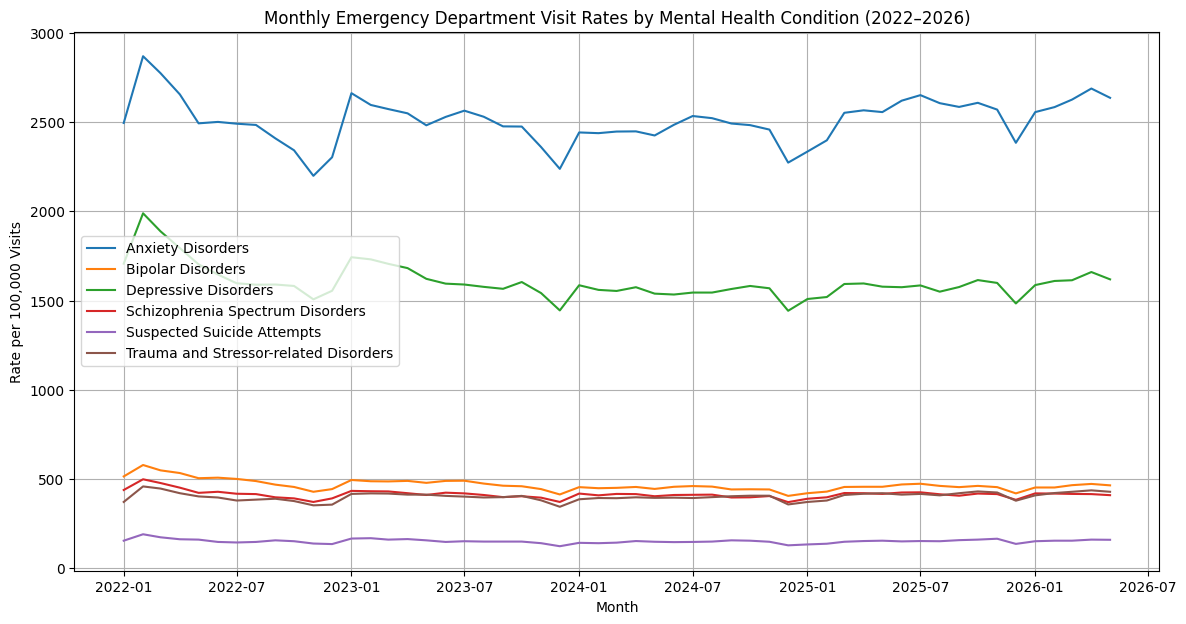

In [38]:
# Plotting Monthly Growth


growth_data = overall_data[
    overall_data["month_end"] >= "2022-01-01"
].copy()

plt.figure(figsize=(14,7))

for condition in growth_data["condition"].unique():
    temp = growth_data[growth_data["condition"] == condition]

    plt.plot(
        temp["month_end"],
        temp["rate_per_100000_visits"],
        label=condition
    )

plt.title("Monthly Emergency Department Visit Rates by Mental Health Condition (2022–2026)")
plt.xlabel("Month")
plt.ylabel("Rate per 100,000 Visits")
plt.legend()
plt.grid(True)

plt.show()

- The trend line chart above demonstrates how
each mental health condition changed month by month from January 2022 through May 2026.

Limitations:
- The dataset contains observations only through May 2026 rather than the complete 2026 calendar year. Consequently, the trend analysis includes all available monthly observations from January 2022 through May 2026, and the growth summary compares the first available month (January 2022) with the last available month (May 2026).

- An alternative approach would have been to compare only January–May across all years to account for the partial 2026 data. However, this would have excluded June–December observations from earlier years, reducing the amount of information used in the analysis. Therefore, the monthly trend analysis was performed using all available observations, while the growth summary compares the first and last available months of the study period.

In [39]:
# Table displaying change in growth

growth_table = growth_data.pivot_table(
    index="condition",
    columns="month_end",
    values="rate_per_100000_visits",
    aggfunc="mean"
)

start = growth_table.columns.min()
end = growth_table.columns.max()

growth_table["Absolute Change"] = (
    growth_table[end] -
    growth_table[start]
)

growth_table["Percent Change"] = (
    growth_table["Absolute Change"] /
    growth_table[start]
) * 100

growth_table = growth_table.sort_values(
    "Percent Change",
    ascending=False
)

growth_table[["Absolute Change","Percent Change"]]

month_end,Absolute Change,Percent Change
condition,,
Trauma and Stressor-related Disorders,57.0,15.322581
Anxiety Disorders,141.0,5.651303
Suspected Suicide Attempts,5.0,3.225806
Depressive Disorders,-88.0,-5.155243
Schizophrenia Spectrum Disorders,-29.0,-6.605923
Bipolar Disorders,-50.0,-9.708738


- The table above calculates the absolute and percent change between the first available month of 2022 (January) and the last available month of 2026 (May).

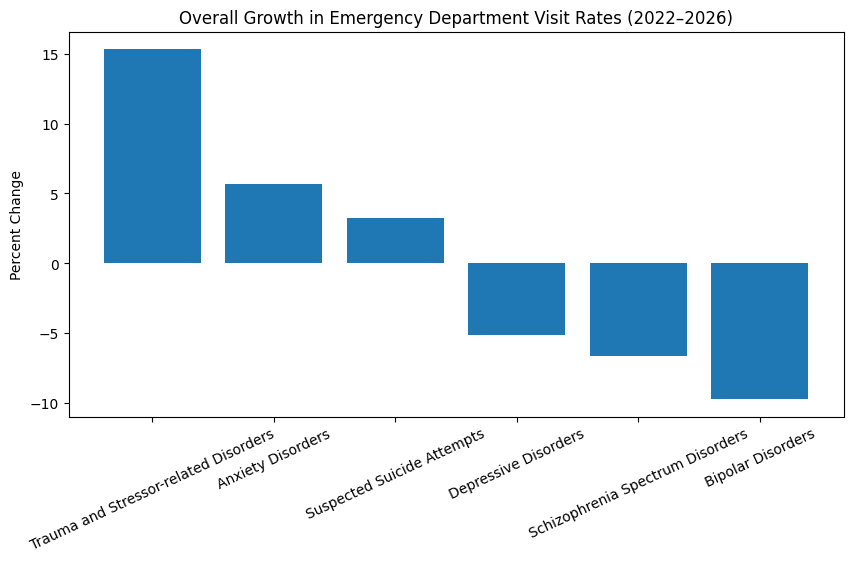

In [40]:
# Growth Ranking Bar Chart
plt.figure(figsize=(10,5))

plt.bar(
    growth_table.index,
    growth_table["Percent Change"]
)

plt.title("Overall Growth in Emergency Department Visit Rates (2022–2026)")
plt.ylabel("Percent Change")
plt.xticks(rotation=25)

plt.show()

- Trauma and Stressor-related disorders seem to have the greatest percent change with about a 15% increase from 2022-2026
- Bipolar disorders had the greatest decrease with about a 10% decrease from 2022-2026

## Inferential Statistics: Linear Regression

- Linear Regression will help to show whether the full set of monthly observations supports a consistent overall upward or downward linear trend, and estimates its rate.
- When we consider all of the monthly data points from 2022–May 2026, is there a consistent overall upward or downward trend in the ED visit rate for each condition?

### Null and Alternative Hypotheses
H_0: There is no linear relationship between time and emergency department visit rates for  mental health conditions.

H_a: There is a linear relationship between time and emergency department visit rates for mental health conditions.

H_0: b1 = 0

H_a: b1 ≠ 0

### Regression Model

y^ ​= b0 ​+ b1​(x)


↓



visit rate = intercept + slope (month_number)

- Dependent variable (Y): rate_per_100000_visits
- Independent variable (X): time known as 'month_end' will be represented as month_number
- Unit of analysis: one monthly observation
- Time period: January 2022 through May 2026
- Models: one regression for each condition

The reason we convert dates (e.g. January 2022) into month_number is because regression needs a numeric predictor. We define:

Jan 2022 = 0

Feb 2022 = 1

Mar 2022 = 2
...

May 2026 = 52

In [42]:
# Create a copy for regression
regression_data = growth_data.copy()

# Number each month from the first observation
regression_data["month_number"] = (
    (regression_data["month_end"].dt.year - regression_data["month_end"].dt.year.min()) * 12
    + regression_data["month_end"].dt.month
    - regression_data["month_end"].dt.month.min()
)

In [47]:
results = []

for condition in regression_data["condition"].unique():

    temp = regression_data[
        regression_data["condition"] == condition
    ]

    regression = linregress(
        temp["month_number"],
        temp["rate_per_100000_visits"]
    )

    results.append({
        "Condition": condition,
        "Slope": regression.slope,
        "Intercept": regression.intercept,
        "R²": regression.rvalue**2,
        "P-value": regression.pvalue
    })

regression_results = (
    pd.DataFrame(results)
      .sort_values("Slope", ascending=False)
)

regression_results.round(4)

,Condition,Slope,Intercept,R²,P-value
0,Anxiety Disorders,0.7636,2489.9015,0.0088,0.5034
5,Trauma and Stressor-related Disorders,0.3287,393.6059,0.0482,0.1140
4,Suspected Suicide Attempts,-0.1280,155.3480,0.0309,0.2080
3,Schizophrenia Spectrum Disorders,-0.4502,425.9874,0.0995,0.0214
1,Bipolar Disorders,-1.2209,498.6855,0.3440,0.0000
2,Depressive Disorders,-2.8966,1679.4067,0.2192,0.0004


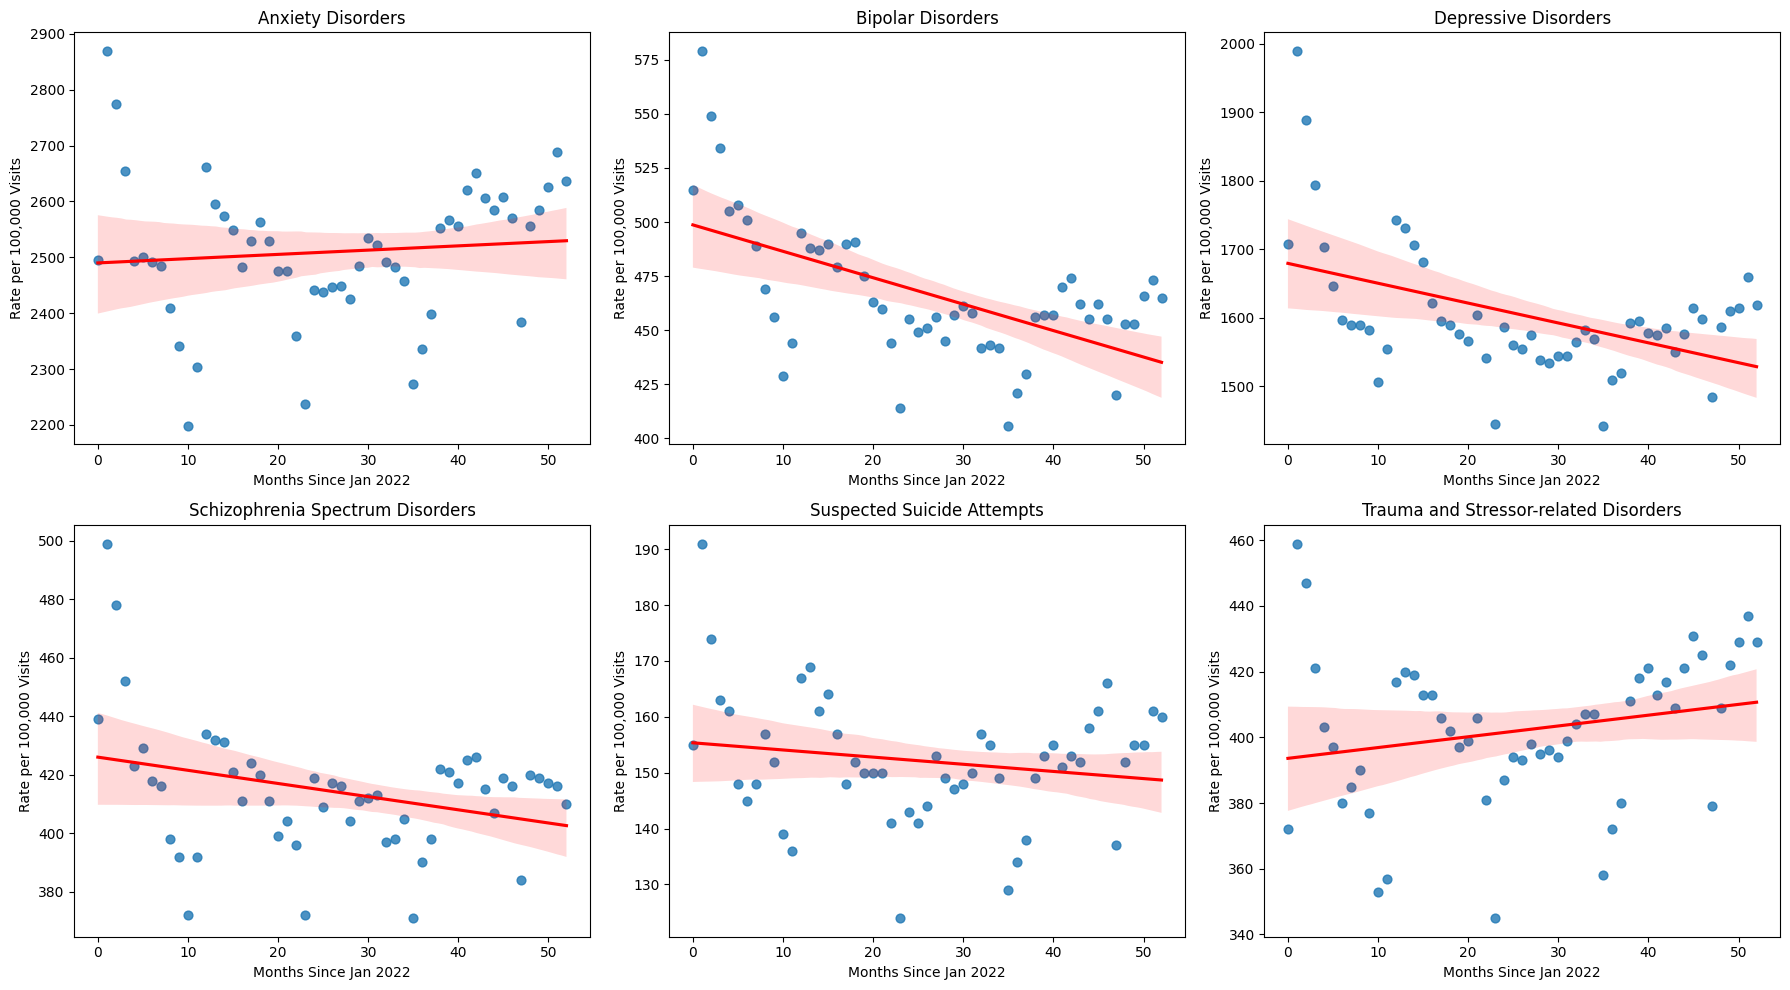

In [49]:
# Plotting linear regression
conditions = regression_data["condition"].unique()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, condition in zip(axes, conditions):

    temp = regression_data[
        regression_data["condition"] == condition
    ]

    sns.regplot(
        data=temp,
        x="month_number",
        y="rate_per_100000_visits",
        ax=ax,
        scatter_kws={"s":40},
        line_kws={"color":"red"}
    )

    ax.set_title(condition)
    ax.set_xlabel("Months Since Jan 2022")
    ax.set_ylabel("Rate per 100,000 Visits")

plt.tight_layout()
plt.show()

## Linear Regression Hypothesis Decisions

(using a significance level of α = 0.05)

- **Condition: Anxiety Disorders.**
At the 5% significance level (α = 0.05), the p-value (0.5034) was greater than α. Therefore, we fail to reject the null hypothesis Ho. There is insufficient statistical evidence to conclude that anxiety disorder emergency department visit rates changed significantly over time.

- **Condition: Trauma & Stressor-related Disorders.**
At the 5% significance level (α = 0.05), the p-value (0.1140) was greater than α. Therefore, we fail to reject the null hypothesis Ho. There is insufficient statistical evidence to conclude that trauma and stressor-related disorder emergency department visit rates changed significantly over time.

- **Condition: Suspected Suicide Attempts.**
At the 5% significance level (α = 0.05), the p-value (0.2080) was greater than α. Therefore, we fail to reject the null hypothesis Ho. There is insufficient statistical evidence to conclude that suspected suicide attempt emergency department visit rates changed significantly over time.

- **Condition: Schizophrenia Spectrum Disorders.**
At the 5% significance level (α = 0.05), the p-value (0.0214) was less than α. Therefore, we reject the null hypothesis Ho. There is sufficient statistical evidence to conclude that schizophrenia spectrum disorder department visit rates changed significantly over time.

- **Condition: Bipolar Disorders.**
At the 5% significance level (α = 0.05), the p-value (<0.001) was less than α. Therefore, we reject the null hypothesis Ho. There is sufficient statistical evidence to conclude that bipolar disorder department visit rates changed significantly over time.

- **Condition: Depressive Disorders.**
At the 5% significance level (α = 0.05), the p-value (0.0004) was less than α. Therefore, we reject the null hypothesis Ho. There is sufficient statistical evidence to conclude that depressive disorder department visit rates changed significantly over time.





### Conclusion

Endpoint growth analysis identified Trauma and Stressor-related Disorders as having the largest relative increase between January 2022 and May 2026 (+15.3%), followed by Anxiety Disorders (+5.7%). However, simple linear regression did not identify statistically significant upward linear trends for Trauma (p = 0.114) or Anxiety (p = 0.503). In contrast, Depressive, Bipolar, and Schizophrenia Spectrum Disorders demonstrated statistically significant downward linear trends over the study period.

- Trauma-related and anxiety-related ED visit rates exhibited the largest endpoint increase. Although regression analysis did not identify a statistically significant linear upward trend, the observed increases may warrant continued monitoring by hospital administrators to determine whether the pattern persists over a longer period.